In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv(r"house_price_dataset.csv")
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [5]:
data.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [6]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [7]:
data.corr()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


<Axes: >

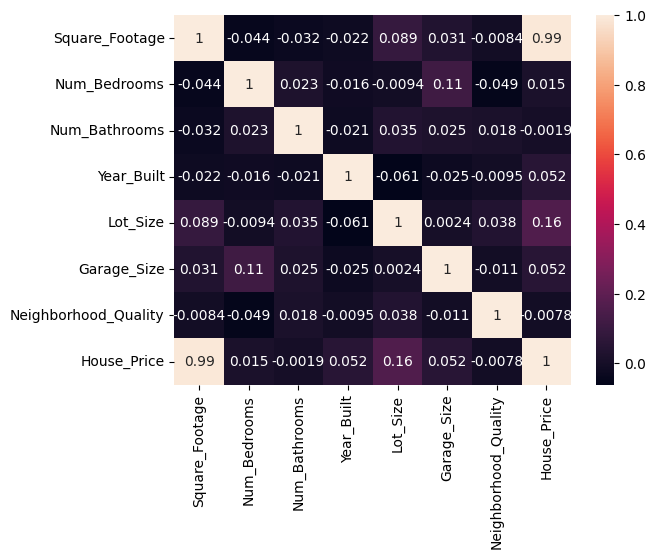

In [8]:
sns.heatmap(data.corr(), annot=True)

In [9]:
data.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262382.852274
1,4272,3,3,2016,4.753014,1,6,985260.854490


<Axes: ylabel='House_Price'>

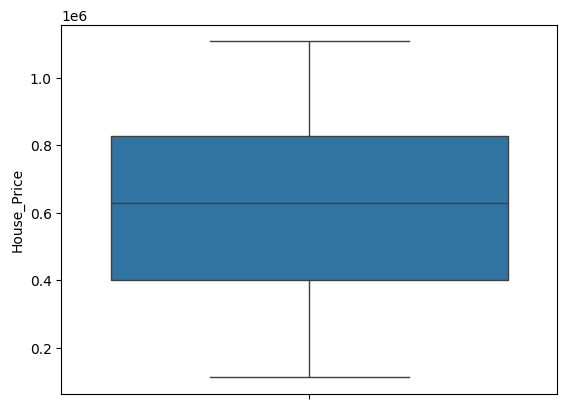

In [10]:
sns.boxplot(y='House_Price', data=data)

In [11]:
X = data.drop('House_Price', axis=1)
X.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6


In [14]:
pd.set_option('display.float_format', '{:.4f}'.format) 

In [15]:
y = data['House_Price']
y

0      262382.8523
1      985260.8545
2      777977.3901
3      229698.9187
4     1041740.8589
          ...     
995    701493.9971
996    683723.1607
997    572024.0236
998    964865.2986
999    742599.2533
Name: House_Price, Length: 1000, dtype: float64

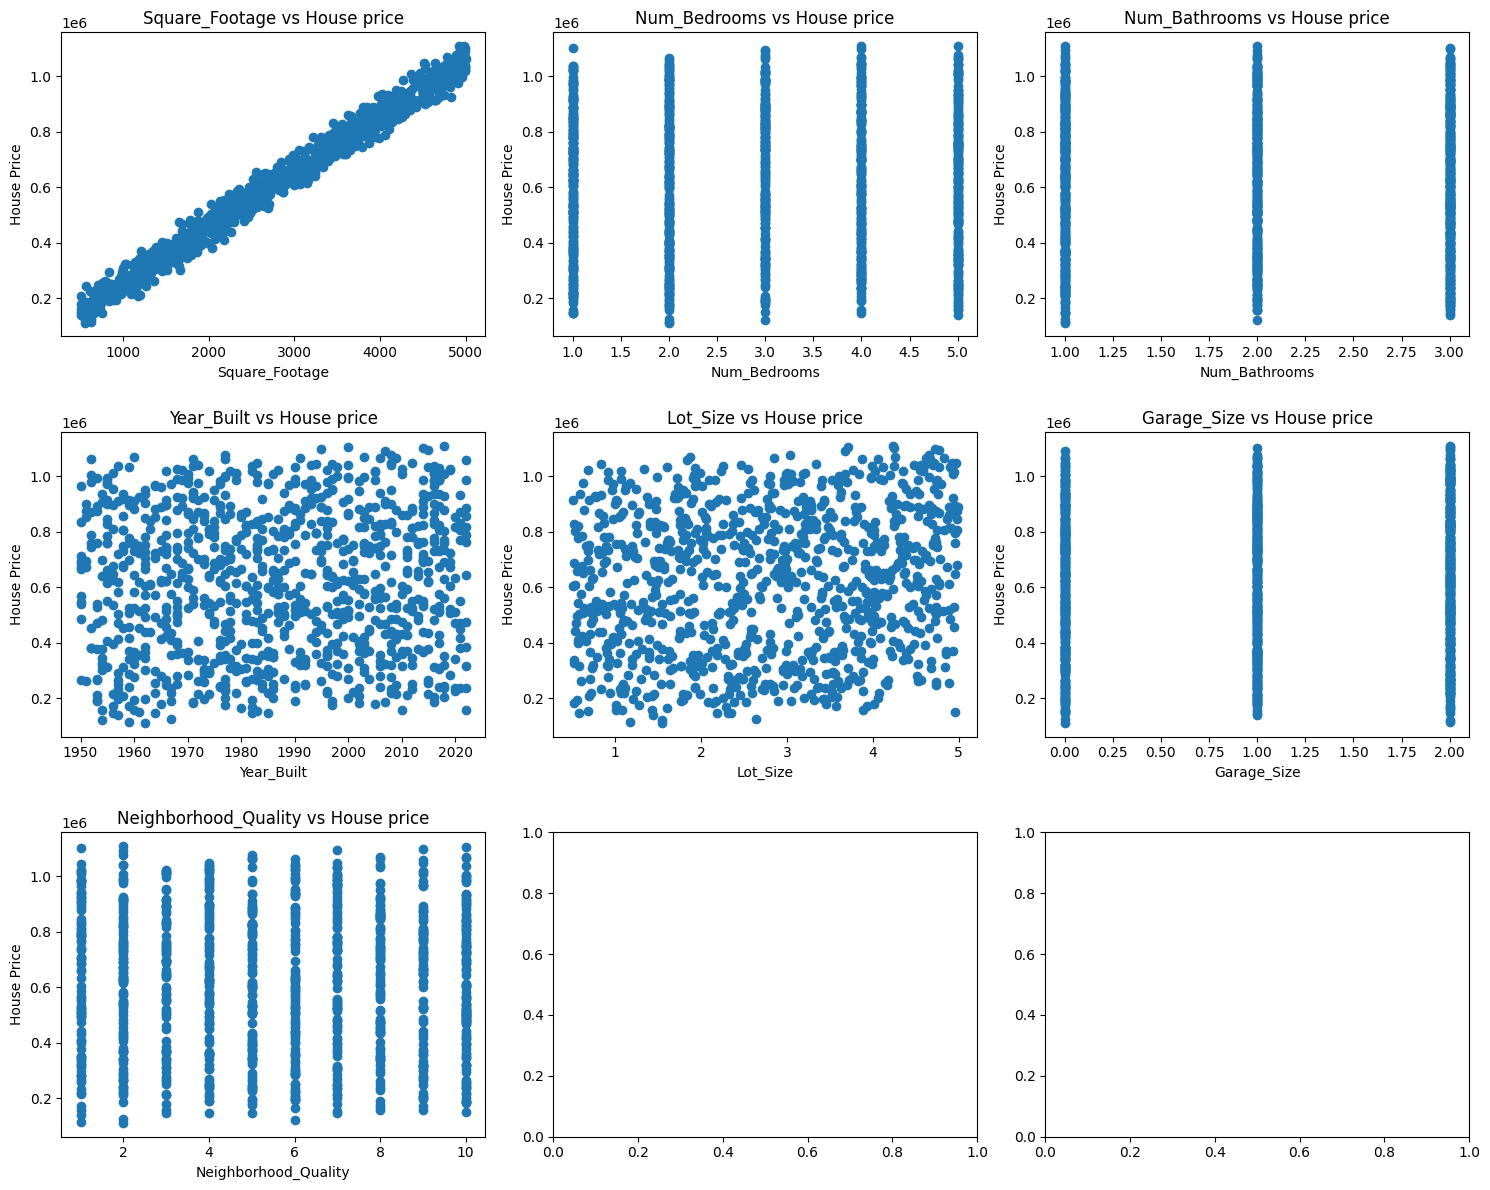

In [26]:
import math
fig_count = len(X.columns)
col = 3
row = math.ceil(fig_count / col)
fig, axes = plt.subplots(row, col, figsize=(15,row * 4))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y)
    axes[i].set_title(f"{col} vs House price")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('House Price')
plt.tight_layout()
plt.show()

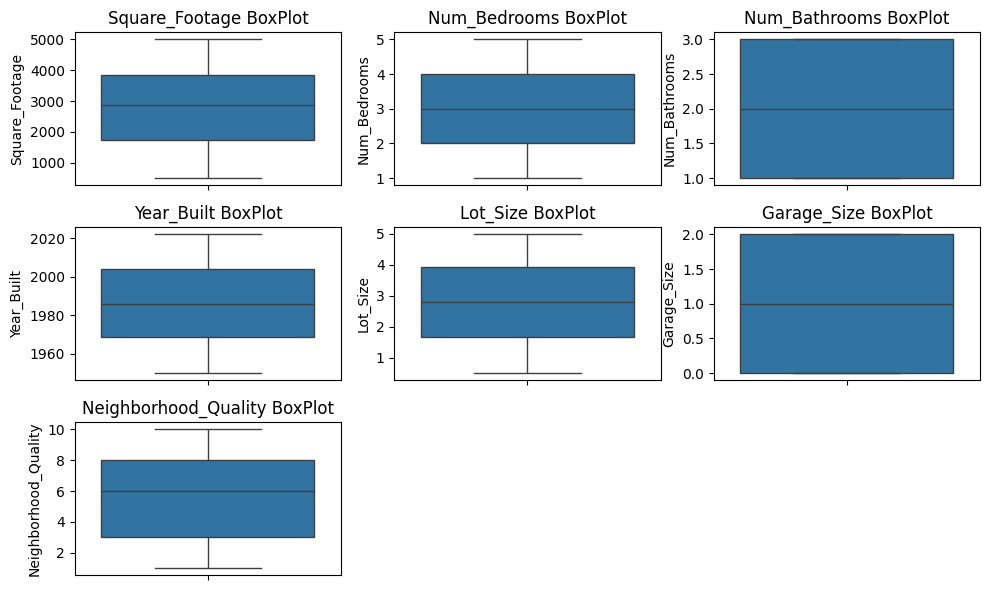

In [34]:
plt.figure(figsize=(10,6))
for i, column in enumerate(X.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(X[column])
    plt.title(f"{column} BoxPlot")
plt.tight_layout()
plt.show()

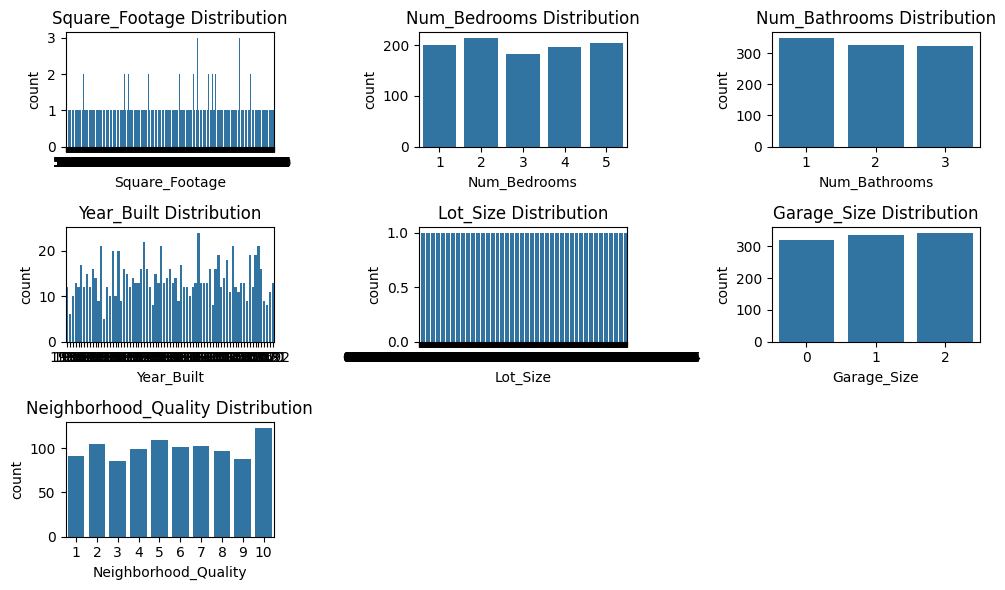

In [39]:
plt.figure(figsize=(10,6))
for i, column in enumerate(X.columns):
    plt.subplot(3,3, i+1)
    sns.barplot(data[column].value_counts())
    plt.title(f"{column} Distribution")
plt.tight_layout()
plt.show()

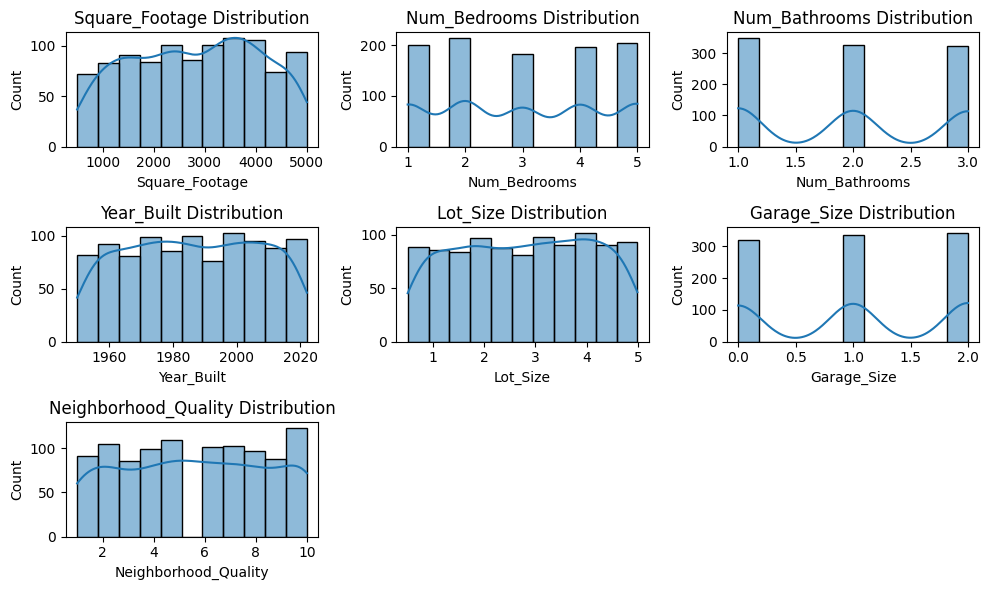

In [43]:
plt.figure(figsize=(10,6))
for i, column in enumerate(X.columns):
    plt.subplot(3,3,i+1)
    sns.histplot(data[column], kde=True)
    plt.title(f"{column} Distribution")
plt.tight_layout()
plt.show()

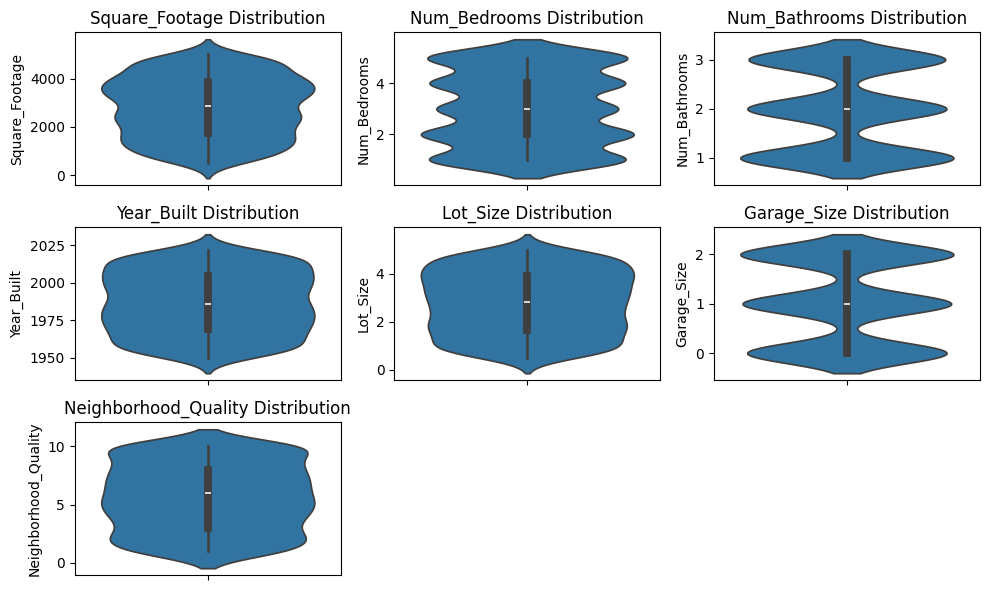

In [45]:
plt.figure(figsize=(10,6))
for i, column in enumerate(X.columns):
    plt.subplot(3,3,i+1)
    sns.violinplot(data[column])
    plt.title(f"{column} Distribution")
plt.tight_layout()
plt.show()

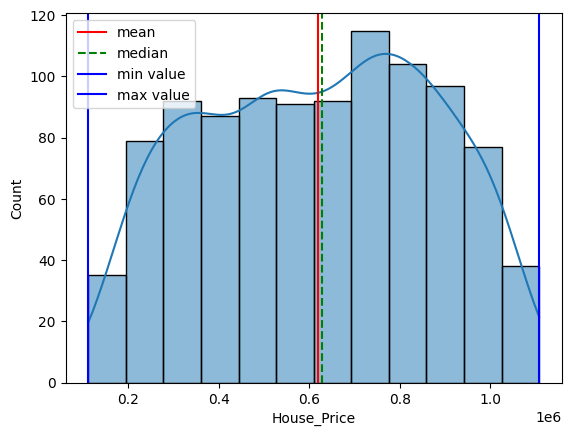

In [52]:
sns.histplot(x='House_Price', data=data, kde=True)
plt.axvline(data.House_Price.mean(), color='red', label='mean')
plt.axvline(data.House_Price.median(), color='green', linestyle='--',label='median')
plt.axvline(data.House_Price.min(), color='blue', label='min value')
plt.axvline(data.House_Price.max(), color='blue', label='max value')
plt.legend()
plt.show()

<Axes: xlabel='Square_Footage', ylabel='House_Price'>

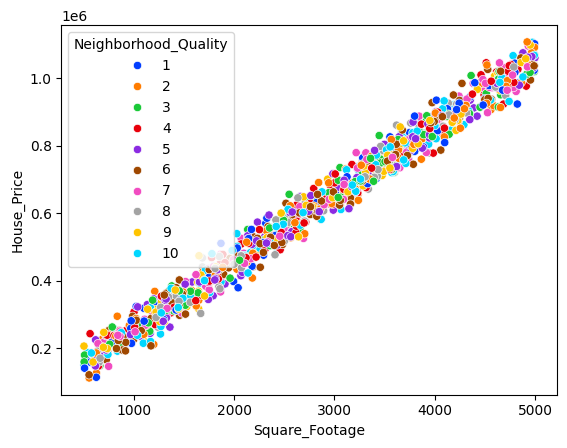

In [55]:
sns.scatterplot(x='Square_Footage', y='House_Price', data=data, hue='Neighborhood_Quality', palette='bright')

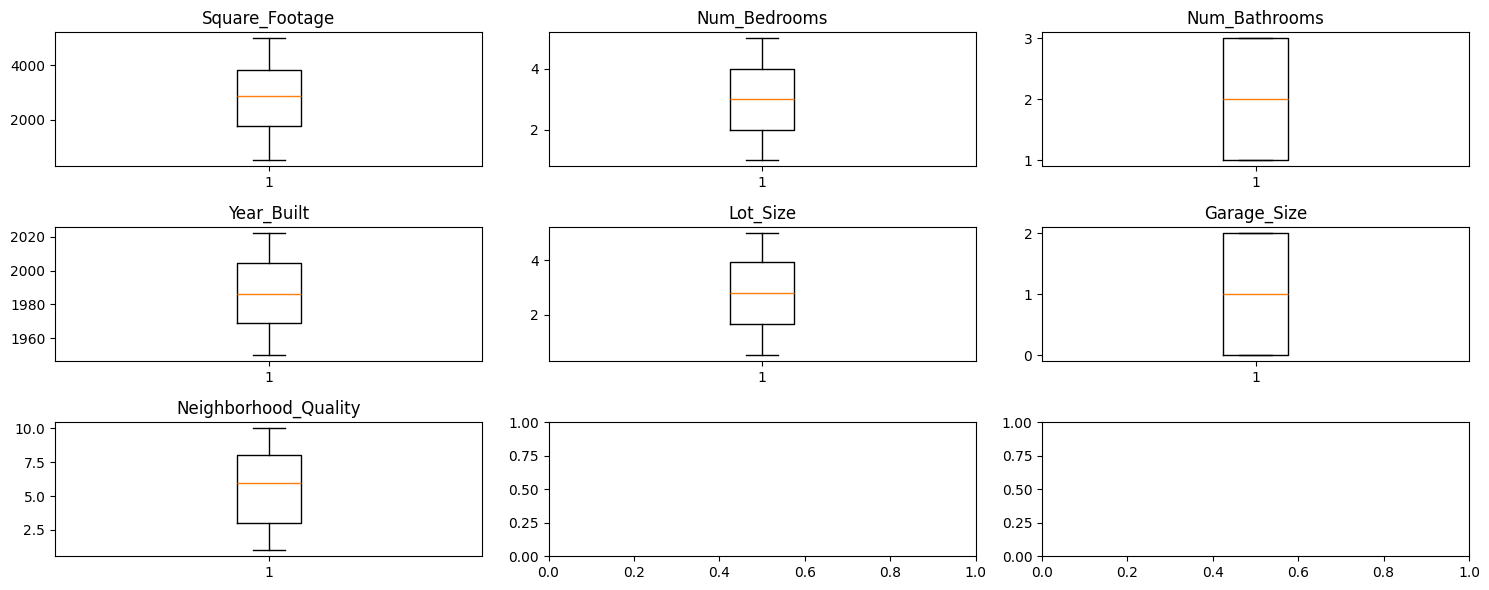

In [77]:
data_columns = len(X.columns)
col = 3
row = math.ceil(data_columns / col)
fig, axes = plt.subplots(row,col, figsize=(15,6))
axes = axes.flatten()

for i, column in enumerate(X.columns):
    axes[i].boxplot(x=X[column])
    axes[i].set_title(f"{column}")
plt.tight_layout()
plt.show()

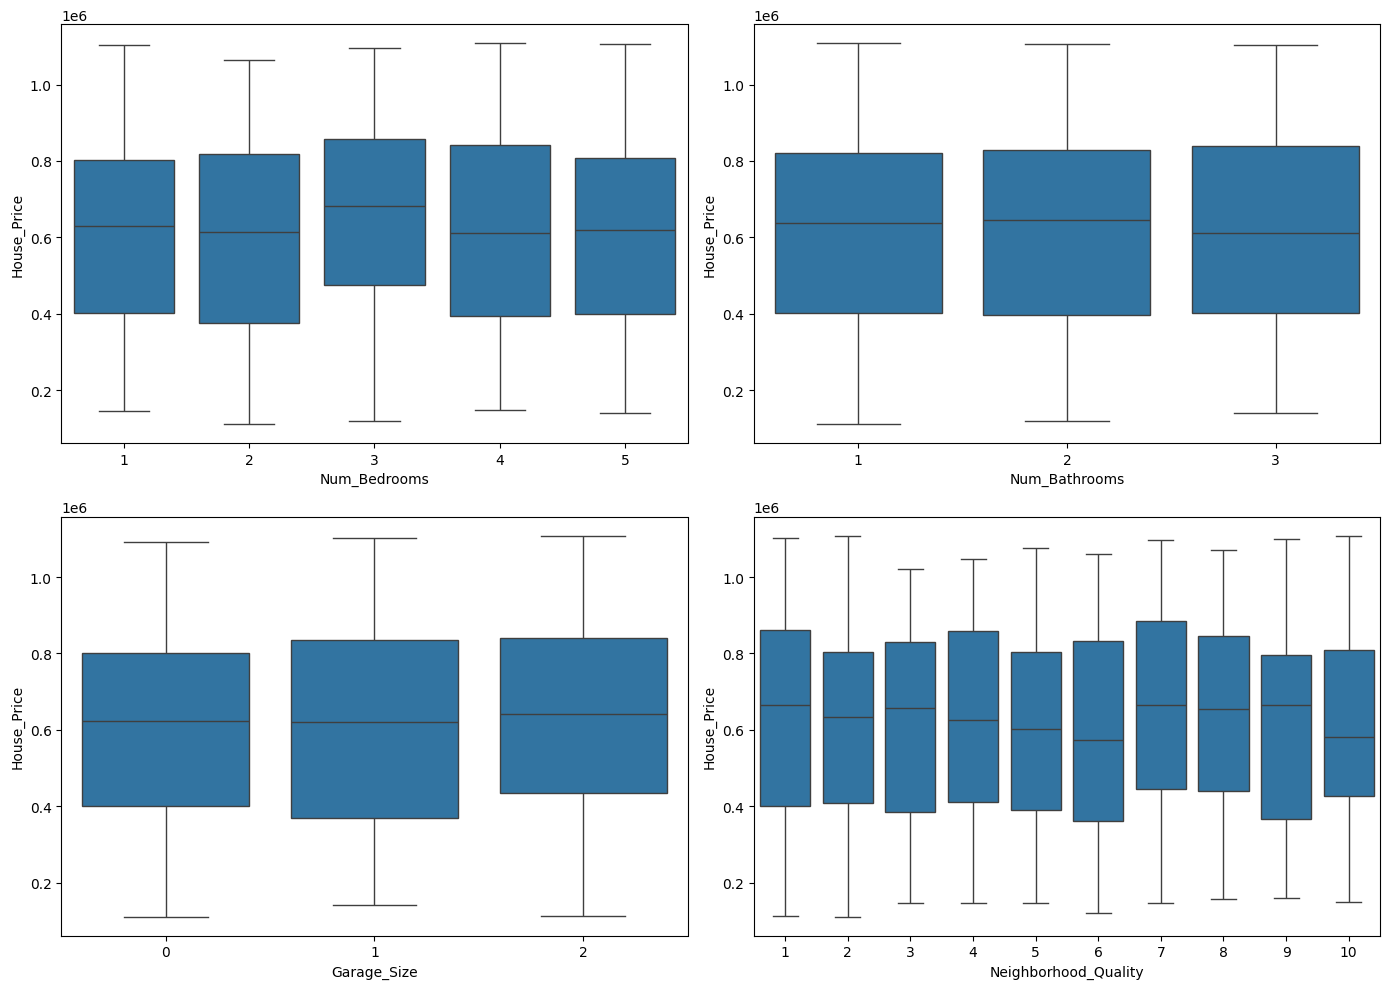

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
sns.boxplot(x='Num_Bedrooms', y='House_Price', data=data, ax=axes[0,0])
sns.boxplot(x='Num_Bathrooms', y='House_Price', data=data, ax=axes[0,1])
sns.boxplot(x='Garage_Size', y='House_Price', data=data, ax=axes[1,0])
sns.boxplot(x='Neighborhood_Quality', y='House_Price', data=data, ax=axes[1,1])
plt.tight_layout()

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [79]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [80]:
X.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.5996,0,5
1,4272,3,3,2016,4.7530,1,6


In [81]:
y

0      262382.8523
1      985260.8545
2      777977.3901
3      229698.9187
4     1041740.8589
          ...     
995    701493.9971
996    683723.1607
997    572024.0236
998    964865.2986
999    742599.2533
Name: House_Price, Length: 1000, dtype: float64

In [82]:
scaler = StandardScaler()

In [89]:
# scaled X_train, X_test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [90]:
# create model
linear = LinearRegression()

In [91]:
# train model with 'X_train_scaled' and 'y_train' dataset
linear.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[249787.91, 14524.73, 6695.91,..., 19088.11, 4219.45, 335.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.186e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[30.57,30.23,29.11,...,27.67,26.54,25.6 ]"


In [92]:
# predict the value using X_test_scaled
y_pred = linear.predict(X_test_scaled)

In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [94]:
print("R2 score: ", r2_score(y_test, y_pred))
print("Mean squared error: ", mean_squared_error(y_test,y_pred))
print("Root mean squared error: ", root_mean_squared_error(y_test,y_pred))
print("Mean absolute error: ", mean_absolute_error(y_test,y_pred))

R2 score:  0.9980776476391371
Mean squared error:  123912636.09820361
Root mean squared error:  11131.605279482543
Mean absolute error:  9136.432140485094


In [95]:
from sklearn.pipeline import Pipeline

In [96]:
pipeline = Pipeline(steps = [('scaler', StandardScaler()), ('model', LinearRegression())])

In [97]:
pipeline.fit(X_test,y_test)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Square_Footage','Num_Bedrooms','Num_Bathrooms',...,'Lot_Size', 'Garage_Size','Neighborhood_Quality']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [99]:
y_pred_2 = pipeline.predict(X_test)
y_pred_2[:10]

array([ 869611.08206301,  489505.48144555,  947831.65654267,
       1037477.38965144,  777521.4639799 ,  732687.06439741,
        996881.29179001,  886653.4057679 ,  797302.33974542,
        933786.41460365])

In [101]:
print("R2 score: ", r2_score(y_test, y_pred_2))
print("Mean squared error: ", mean_squared_error(y_test,y_pred_2))
print("Root mean squared error: ", root_mean_squared_error(y_test,y_pred_2))
print("Mean absolute error: ", mean_absolute_error(y_test,y_pred_2))

R2 score:  0.99847325989369
Mean squared error:  98411922.32042667
Root mean squared error:  9920.278338858576
Mean absolute error:  7898.025677197687
